# Clean file with modules

In [1]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
parent_dir1 = os.path.abspath(os.path.join(parent_dir, '..'))
sys.path.append(parent_dir1)

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from torch import nn
import torch.nn.functional as F
from simspice.data.SproutDataset_NeMg import SproutDataset
from torch.utils.data import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint
import torch
import numpy as np
import matplotlib.pyplot as plt
from cuml.cluster.hdbscan import HDBSCAN

import matplotlib.pyplot as plt
from lightly.loss import NTXentLoss

import simspice.utils.inverse_mapping_functions as imf
import simspice.models.SimSiam_Architecture_Jul26 as SA
import wandb
#import umap.umap_ as umap
import tqdm
from datetime import datetime

plt.rcParams['image.origin'] = 'lower'

BATCH_SIZE = 128

In [2]:
simspice = "/d0/tvaresano/SimSPICE/"

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [40]:
dataset_path = simspice+"spectra_Feb2023_NeMg.nc"

dataset = SproutDataset(dataset_path=dataset_path,
    augmentation_type="single",
    csv_files=simspice + "L2_names.csv",
    log_space=False, normalize_intensity=False,
    shift_range=(-0.4, 0.4),
    sigma_shift=0.1, sigma_gain=0.1, add_noise=True,
    gain_range=(0.05, 10), type_distrib_gain='Gaussian')

dataset_none = SproutDataset(dataset_path=simspice+"spectra_9Jan2023_MgNe.nc",
    augmentation_type=None, csv_files=simspice + "L2_names.csv",
    log_space=False, normalize_intensity=False,)

dataloader = DataLoader(dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, drop_last=True,
    num_workers=0, pin_memory=torch.cuda.is_available())

In [63]:
id = 'Simsiam_new_gain0.05-10.0_gauss_distrib_100epoch'

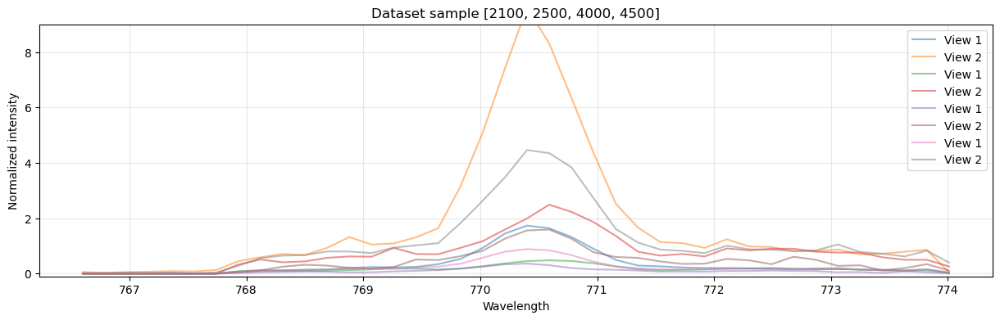

In [64]:
sample_indexs = [2100,2500,4000,4500]

wavelength = dataset.all_spectra.isel(index=sample_indexs[0])["wvl"].values
plt.figure(figsize=(15, 4))
for x in sample_indexs:
    view_1, view_2 = dataset[x]
    view_1 = view_1.squeeze().numpy()
    view_2 = view_2.squeeze().numpy()
    plt.plot(wavelength, view_1, label="View 1", alpha=0.5)
    plt.plot(wavelength, view_2, label="View 2", alpha=0.5)
plt.xlabel("Wavelength")
plt.ylabel("Normalized intensity"), plt.ylim(-.1,9.)
plt.title(f"Dataset sample {sample_indexs}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Train model

In [ ]:
epoch_nbr = 100

model = SA.SpectralSimSiam(
    backbone_embedding_dim=128,  # 256
    projection_hidden_dim=256,  # 512
    projection_output_dim=256, # 128 default
    prediction_hidden_dim = 128,
    learning_rate=3e-4,
    weight_decay=1e-4,
    maximum_epochs=epoch_nbr,)

accelerator = "gpu" if torch.cuda.is_available() else "cpu"

wandb_logger = WandbLogger(project="runs_single_augmentation_MgNe", name=f"{id}_{datetime.today().strftime('%Y-%m-%d')}", log_model=True)

trainer = pl.Trainer(max_epochs=epoch_nbr, devices=1, accelerator=accelerator, logger=wandb_logger)
trainer.fit(model=model, train_dataloaders=dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name            | Type                     | Params | Mode 
---------------------------------------------------------------------
0 | backbone        | SpectralCNNTransformer   | 800 K  | train
1 | projection_head | SimSiamProjectionHead    | 164 K  | train
2 | prediction_head | SimSiamPredictionHead    | 66.0 K | train
3 | criterion       | NegativeCosineSimilarity | 0      | train
---------------------------------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.126     Total estimated model params size (MB)
97        Modules in train mode
0         Modules in eval mode


Epoch 48:  92%|█████████▏| 837/907 [02:07<00:10,  6.56it/s, v_num=abw9, train_loss_step=-0.996, train_loss_epoch=-0.996]

## If loading from previous checkpoint

In [ ]:
# checkpoint = simspice+"\\notebooks\\FullDataset_64_doubleAug_normalized_spec\\k81c85sl\\checkpoints\\epoch=4-step=9075.ckpt"
# model = SA.SimSiam.load_from_checkpoint(checkpoint)  # Continue epochs

# accelerator = "gpu" if torch.cuda.is_available() else "cpu"
# wandb_logger = WandbLogger(project="FullDataset_64_doubleAug_normalized_spec", log_model=True)
# trainer = pl.Trainer(max_epochs=10, devices=1, accelerator=accelerator, logger=wandb_logger)
# trainer.fit(model=model, train_dataloaders=dataloader)

-------------------------------------------------------------------

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

outputs = []

with torch.no_grad():
    for i in tqdm.tqdm(range(len(dataset_none))):
        spec = dataset_none[i].unsqueeze(0).to(device)

        embedding = model.encode(spec)

        outputs.append(embedding.squeeze(0).cpu().numpy() )

stacked_outputs = np.stack(outputs, axis=0)
print(stacked_outputs.shape)

100%|██████████| 116160/116160 [04:52<00:00, 397.46it/s]


(116160, 128)


In [86]:
# checkpoint = "C:\\Users\\tania\Documents\CU Boulder\CU Alpine\models_ckpts\single_epoch=4-step=45750.ckpt"
# dataset_none = SproutDataset(dataset_path=dataset_path, augmentation_type=None)
# outputs = SA.run_model(checkpoint, dataset_none)

In [ ]:
stacked_outputs = np.stack(outputs).squeeze()
stacked_outputs.shape
np.save(simspice+f'notebooks/jobs/model_outputs/stacked_outputs_single_9Jan23_{id}.npy', stacked_outputs)

In [6]:
# id = 'CNN_VICReg_updated'
stacked_outputs = np.load(simspice+f'notebooks/jobs/model_outputs/stacked_outputs_single_9Jan23_{id}.npy')

## Reducing dimensionality

In [ ]:
from cuml.manifold import UMAP
from sklearn.preprocessing import StandardScaler

In [14]:
stacked_outputs.shape

(116160, 128)

In [ ]:
# Shape: (number_of_spectra, 256)
X = np.asarray(stacked_outputs, dtype=np.float32)

# Standardize the embedding dimensions
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

umap_cluster = UMAP(
    n_components=25,
    n_neighbors=100,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

X_umap_cluster = umap_cluster.fit_transform(X_scaled)

print(X_umap_cluster.shape)
# Expected: (number_of_spectra, 15)

[2026-07-28 12:03:37.061] [CUML] [info] build_algo set to brute_force_knn because random_state is given
(116160, 25)


In [ ]:
xs = [10,15,50,100,200,300]
ys = [5,10,15,20,100]
# cluster_print_noise_fraction(xs, ys, X=X_umap_cluster)
# plot_cluster_umap2D(xs,ys,n_neighbors=30)

## Clustering

In [ ]:
for x in xs:
    for y in tqdm.tqdm(ys):
        clusterer = HDBSCAN(min_cluster_size=x, min_samples=y, metric='euclidean') # <=> cosine?
        # clusterer.fit(stacked_outputs) 
        clusterer.fit(X_umap_cluster) 
        labels = clusterer.labels_
        np.save(simspice+f'notebooks/jobs/clustering_outputs/minclus{x}_minsamp{y}_MgNe.npy', labels)

100%|██████████| 5/5 [00:04<00:00,  1.11it/s]


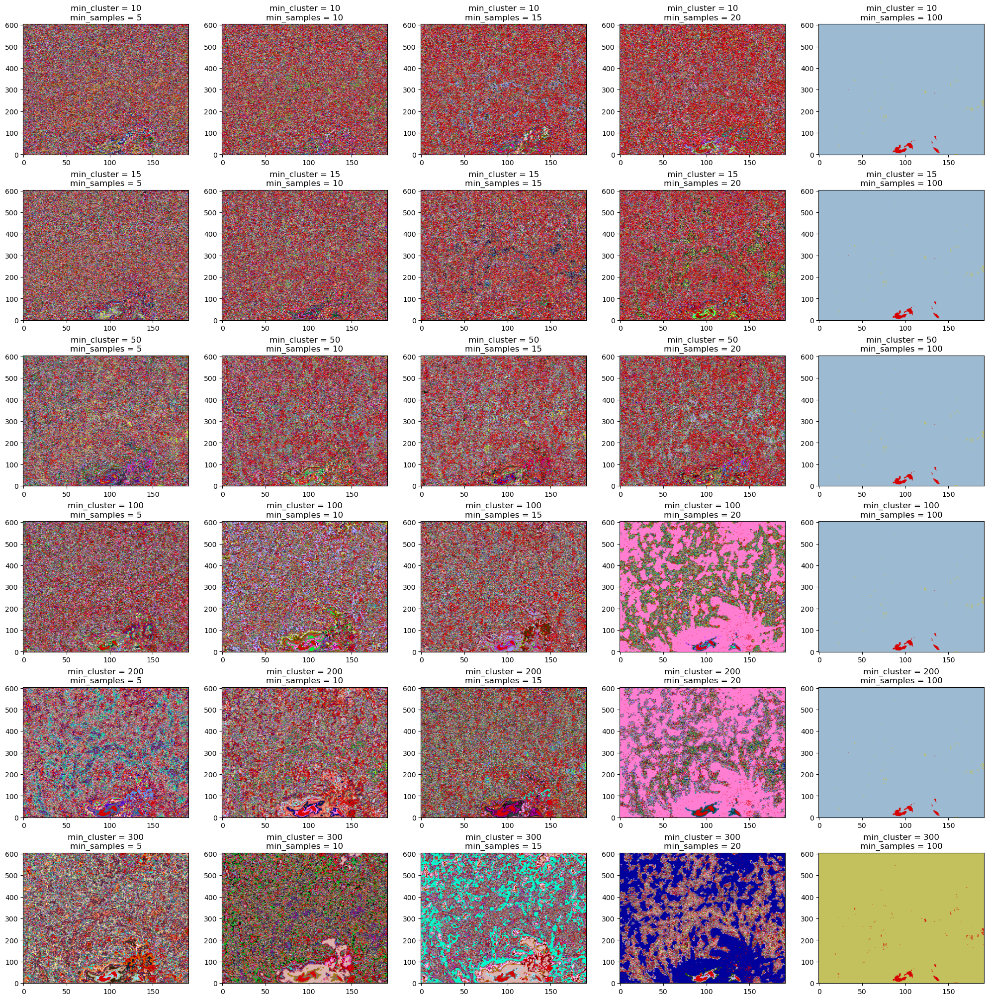

In [ ]:
c=0
fig, axes = plt.subplots(6, 5, figsize=(20, 20), constrained_layout=True)
for x in xs:
    for y in ys:
        ax = axes.flat[c]
        c+=1
        labels = np.load(simspice+f'notebooks/jobs/clustering_outputs/minclus{x}_minsamp{y}_MgNe.npy')
        imf.map_clusters(labels, dataset_path=simspice+'spectra_Feb2023.nc', selected_clusters=None, ax=ax)
        ax.set_title(f"min_cluster = {x}\nmin_samples = {y}")
# fig.suptitle('Feb23_Fulltrained_single32')

## Without UMAP

In [ ]:
for x in xs:
    for y in tqdm.tqdm(ys):
        clusterer = HDBSCAN(min_cluster_size=x, min_samples=y, metric='euclidean') # <=> cosine?
        clusterer.fit(stacked_outputs) 
        labels = clusterer.labels_
        np.save(simspice+f'notebooks/jobs/clustering_outputs/minclus{x}_minsamp{y}_MgNe.npy', labels)

100%|██████████| 5/5 [00:06<00:00,  1.28s/it]


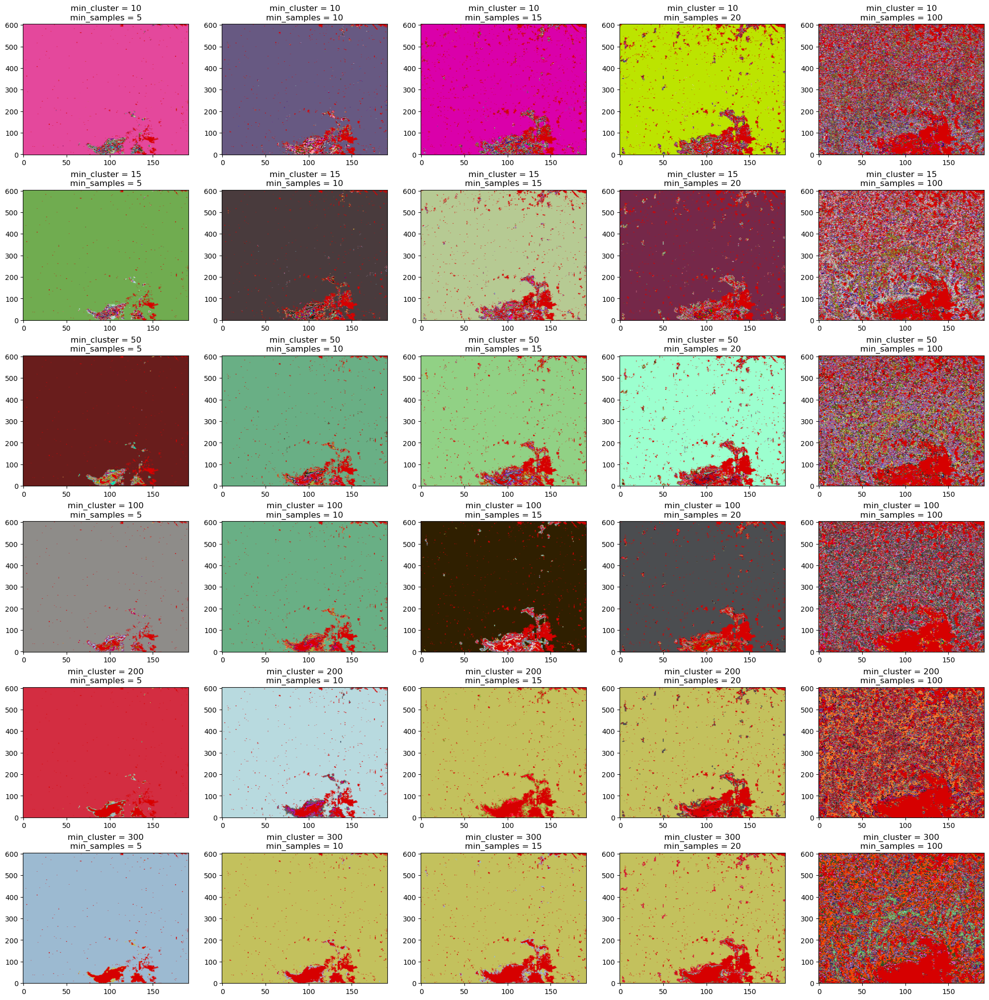

In [ ]:
c=0
fig, axes = plt.subplots(6, 5, figsize=(20, 20), constrained_layout=True)
for x in xs:
    for y in ys:
        ax = axes.flat[c]
        c+=1
        labels = np.load(simspice+f'notebooks/jobs/clustering_outputs/minclus{x}_minsamp{y}_MgNe.npy')
        imf.map_clusters(labels, dataset_path=simspice+'spectra_Feb2023.nc', selected_clusters=None, ax=ax)
        ax.set_title(f"min_cluster = {x}\nmin_samples = {y}")
# fig.suptitle('Feb23_Fulltrained_single32')